In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# ── Core data handling ──────────────────────────────────────
import pandas as pd
import numpy as np
from numpy.random import seed

# ── Preprocessing and pipelines ─────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,          # ← replaces KFold for classification
    GridSearchCV,
    cross_val_score
)
from sklearn.compose    import ColumnTransformer
from sklearn.pipeline   import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute     import SimpleImputer

# ── Tree-based classifiers ──────────────────────────────────
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

# ── Evaluation metrics ──────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

# ── Imbalanced-learn ─────────────────────────────────────────
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset

In [21]:
df = pd.read_csv('data/Default.csv')

In [22]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


# 3. Explore & inspect the data

In [23]:
print("Dataset shape:", df.shape)
print(df.info())
print(df.describe())

Dataset shape: (10000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB
None
            balance        income
count  10000.000000  10000.000000
mean     835.374886  33516.981876
std      483.714985  13336.639563
min        0.000000    771.967729
25%      481.731105  21340.462903
50%      823.636973  34552.644802
75%     1166.308386  43807.729272
max     2654.322576  73554.233495


# 4. Check & handle missing values

In [24]:
# Count the number of missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
default    0
student    0
balance    0
income     0
dtype: int64


In [25]:
# Calculate the proportion of missing values per column
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(f"\nMissing percentage: \n{missing_pct.astype(str) + ' %'}")


Missing percentage: 
default    0.0 %
student    0.0 %
balance    0.0 %
income     0.0 %
dtype: str


# 5. Encode the target variable

In [ ]:
# Encode the 'default', No is 0 and Yes is 1
df['default'] = df['default'].map({'No': 0, 'Yes': 1})

   default student      balance        income
0        0      No   729.526495  44361.625074
1        0     Yes   817.180407  12106.134700
2        0      No  1073.549164  31767.138947
3        0      No   529.250605  35704.493935
4        0      No   785.655883  38463.495879
int64


In [28]:
print(df['default'].head())
print(df['default'].unique())
print(df['default'].dtype)

0    0
1    0
2    0
3    0
4    0
Name: default, dtype: int64
[0 1]
int64


# 6. Check class distribution

In [35]:
# Count of each class
print("Class counts:")
print(df['default'].value_counts())

# Convert to the percentage
print()
print("Class percentages:")
print(df['default'].value_counts(normalize=True).mul(100).round(2))

Class counts:
default
0    9667
1     333
Name: count, dtype: int64

Class percentages:
default
0    96.67
1     3.33
Name: proportion, dtype: float64


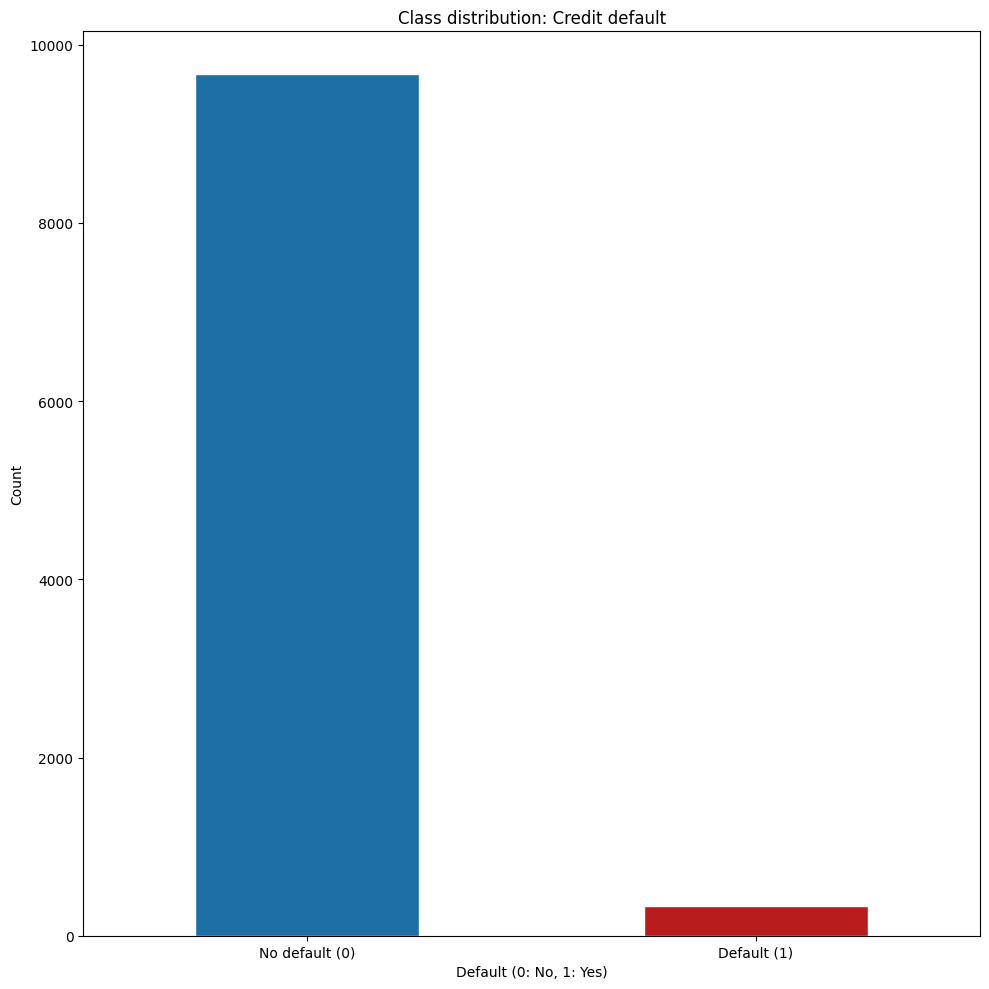

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
df['default'].value_counts().plot(
    kind='bar',
    ax=ax,
    color=['#1d6fa4', '#b91c1c'],
    edgecolor='white', 
    width=0.5
)

ax.set_title('Class distribution: Credit default', fontsize=12)
ax.set_xlabel('Default (0: No, 1: Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

# 8. Correlation Heatmap

In [47]:
# Select numeric colmns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['default', 'balance', 'income']
Categorical features: ['default', 'balance', 'income']


In [54]:
# Make a correlation matrix
cm = df[num_cols].corr()
print(cm)

          default   balance    income
default  1.000000  0.350119 -0.019871
balance  0.350119  1.000000 -0.152243
income  -0.019871 -0.152243  1.000000


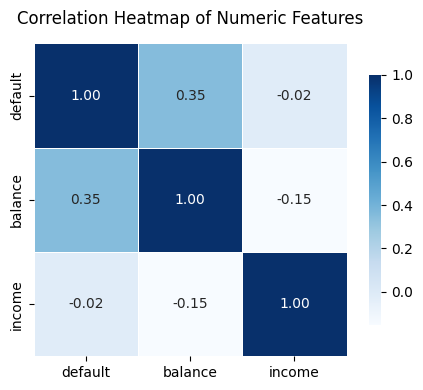

In [55]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()